## 3. Analisi vendite (dataset tips)

In [1]:
%conda install pandas
%conda install matplotlib

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Esegui un’analisi esplorativa focalizzata sulle vendite giornaliere.
Analizza i seguenti aspetti per ogni giorno (day):

1. Il conto medio (total_bill)

2. Il numero totale di osservazioni (conteggio delle righe)

3. Il valore minimo e massimo del conto (total_bill → min / max)

In [35]:
df_bill = df.groupby('day')['total_bill'].agg(
    mean_bill='mean',
    count_bill='count',
    min_bill='min',
    max_bill='max'
)

df_bill

,mean_bill,count_bill,min_bill,max_bill
day,,,,
Fri,17.151579,19,5.75,40.17
Sat,20.441379,87,3.07,50.81
Sun,21.410000,76,7.25,48.17
Thur,17.682742,62,7.51,43.11


Crea una nuova colonna conto_per_persona che sia: total_bill / size

In [15]:
# Creo la colonna e la aggiungo al dataframe
conto_per_persona = df['total_bill'] / df['size']
df['conto_per_persona'] = conto_per_persona

df

,total_bill,tip,sex,smoker,day,time,size,conto_per_persona
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.676667
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.590000
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.335000
242,17.82,1.75,Male,No,Sat,Dinner,2,8.910000


Trova il giorno con il conto medio più alto

In [36]:
df_bill['mean_bill'].idxmax()

'Sun'

Rappresenta graficamente il conto medio (total_bill) per giorno usando un grafico a barre. Ordina i dati dal valore più alto al più basso.
Aggiungi titolo ed etichette agli assi.

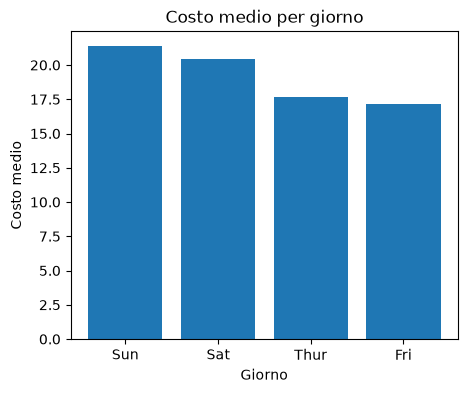

In [40]:
# Reintroduco la colonna day che prima era l'indice
df_bill_reset = df_bill.reset_index()

# Ordino i valori
df_bill_sorted = df_bill_reset.sort_values(by='mean_bill', ascending=False)

plt.figure(figsize=(5, 4))
plt.bar(df_bill_sorted['day'], df_bill_sorted['mean_bill'])
plt.title('Costo medio per giorno')
plt.xlabel('Giorno')
plt.ylabel('Costo medio')
plt.show()